In [ ]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (
    (repo_root / "benchmarks" / "analysis" / "_utils.py").exists()
    and (repo_root / "src" / "genkit").exists()
):
    repo_root = repo_root.parent

for path_entry in [repo_root, repo_root / "src"]:
    if str(path_entry) not in sys.path:
        sys.path.insert(0, str(path_entry))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from benchmarks.evaluate import load_generator_and_data, run_dirs
from genkit._sampling import _orthonormal_embedding, _structured_mode_codebook
from labkit.report import PRETTY_RCPARAMS, format_mean_std_latex

plt.rcParams.update(PRETTY_RCPARAMS)


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
PREFERRED_LABELS = ["GF-Linear", "DDPM-V", "DLPM", "DLPM-Orig", "FM-Orig", "ScoreSDE-Orig"]
STYLE_MAP = {
    "GF-Linear": {"color": "tab:blue", "linestyle": "dashdot", "marker": "^"},
    "DDPM-V": {"color": "tab:green", "linestyle": "solid", "marker": "o"},
    "DLPM": {"color": "tab:orange", "linestyle": "dashed", "marker": "v"},
    "DLPM-Orig": {"color": "tab:red", "linestyle": "dashed", "marker": "s"},
    "FM-Orig": {"color": "tab:purple", "linestyle": "dashdot", "marker": "D"},
}
PERF_METRICS = ["W1", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"]
DATA_DIR = repo_root / "benchmarks" / "analysis" / "data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_MODE_SAMPLES = 4096
N_MODE_REPEATS = 5


def ordered_labels(labels):
    labels = list(labels)
    return [label for label in PREFERRED_LABELS if label in labels] + sorted(label for label in labels if label not in PREFERRED_LABELS)


def latest_batch_dir(suffix: str) -> Path:
    matches = sorted(path for path in DATA_DIR.iterdir() if path.is_dir() and path.name.endswith(suffix))
    if not matches:
        raise FileNotFoundError(f"No batch found under {DATA_DIR} for *{suffix}")
    return matches[-1]


def load_batch_scalars(batch_dir: Path) -> pd.DataFrame:
    frames = []
    for run_dir in run_dirs(batch_dir):
        path = run_dir / "eval" / "scalars.csv.gz"
        if path.exists():
            frame = pd.read_csv(path)
            frame["run_dir"] = run_dir.name
            frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No eval/scalars.csv.gz found under {batch_dir}")
    frame = pd.concat(frames, ignore_index=True)
    for column in ["dataset_alpha", "dataset_dim", "model_alpha", "value", "checkpoint_epoch"]:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def summarize_test_metrics(frame: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    sub = frame[frame["source"] == "test_metrics"].copy()
    summary = (
        sub.groupby(group_cols + ["metric_name"], dropna=False)["value"]
        .agg(mean="mean", std=lambda s: float(s.std(ddof=0)))
        .reset_index()
    )
    summary["std"] = summary["std"].fillna(0.0)
    return summary


def best_parameter_rows(summary: pd.DataFrame, metric_name: str, fixed_cols: list[str]) -> pd.DataFrame:
    sub = summary[summary["metric_name"] == metric_name].copy()
    if sub.empty:
        return sub
    rows = []
    for _, group in sub.groupby(fixed_cols, dropna=False):
        if "model_alpha" in group.columns and not group["model_alpha"].isna().all():
            rows.append(group.nsmallest(1, "mean").iloc[0].to_dict())
        else:
            rows.append(group.iloc[0].to_dict())
    return pd.DataFrame(rows)


def alpha_caption(value) -> str:
    return "" if pd.isna(value) else f"a={float(value):.3g}"


def render_metric_table(summary: pd.DataFrame, metric_name: str, row_key: str, col_key: str, col_labels: dict, *, corner_text: str | None = None):
    winners = best_parameter_rows(summary, metric_name, [col_key, row_key])
    row_labels = ordered_labels(winners[row_key].dropna().unique())
    col_values = sorted(winners[col_key].dropna().unique())
    table = pd.DataFrame("", index=row_labels, columns=col_values, dtype=object)

    for col_value, group in winners.groupby(col_key, dropna=False):
        best_idx = group["mean"].idxmin()
        best_label = group.loc[best_idx, row_key]
        for _, row in group.iterrows():
            table.loc[row[row_key], col_value] = format_mean_std_latex(
                row["mean"],
                row["std"],
                caption=alpha_caption(row.get("model_alpha", np.nan)),
                bold=row[row_key] == best_label,
            )

    fig, ax = plt.subplots(1, 1, figsize=(0.95 + len(table.columns), 0.9 + 0.42 * len(table.index)))
    styled_table(
        ax,
        table.values,
        list(table.index),
        [col_labels[value] for value in table.columns],
        fontsize=8.5,
        scale=(1.0, 1.45),
        corner_text=corner_text or metric_name,
    )
    fig.tight_layout()
    plt.show()




def styled_table(
    ax,
    cell_text,
    row_labels,
    col_labels,
    *,
    fontsize: float = 8.5,
    scale: tuple[float, float] = (1.0, 1.35),
    corner_text=None,
):
    ax.axis("off")
    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(*scale)

    if corner_text is not None:
        corner_width = table[(1, -1)].get_width() if (1, -1) in table.get_celld() else table[(1, 0)].get_width()
        corner_height = table[(0, 0)].get_height()
        table.add_cell(0, -1, width=corner_width, height=corner_height, text=corner_text, loc="center")

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("0.2")
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold")

    return table

def mixture_centers(dataset_cfg: dict, *, device: str, dtype: torch.dtype) -> torch.Tensor:
    params = dataset_cfg["params"]
    dim = int(params["dim"])
    n_modes = int(params.get("n_modes", 16))
    rank = min(int(params.get("rank", 6)), dim)
    structure_seed = int(params.get("structure_seed", 0))
    embedding = _orthonormal_embedding(dim, rank, device=device, dtype=dtype, structure_seed=structure_seed)
    codebook = _structured_mode_codebook(n_modes, rank, device=device, dtype=dtype, structure_seed=structure_seed)
    return float(params.get("mean_scale", 7.5)) * (codebook @ embedding.T)


def occupancy_histogram(x: torch.Tensor, centers: torch.Tensor) -> torch.Tensor:
    assign = torch.cdist(x, centers).argmin(dim=1)
    hist = torch.bincount(assign, minlength=len(centers)).to(dtype=torch.float32)
    return hist / hist.sum().clamp_min(1.0)


def compute_mode_tv_batch(batch_dir: Path, *, device: str, n_samples: int, n_repeats: int) -> pd.DataFrame:
    cache_path = batch_dir / f"_mode_tv_cache_n{n_samples}_r{n_repeats}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    rows = []
    for run_dir in tqdm(run_dirs(batch_dir), desc="ModeTV"):
        if not (run_dir / "checkpoint.pt").exists():
            continue
        generator, _, x_test, config, _ = load_generator_and_data(run_dir, device=device, checkpoint_epoch=None)
        centers = mixture_centers(config["dataset"], device=device, dtype=x_test.dtype)
        x_ref = x_test[: min(n_samples, len(x_test))]
        ref_hist = occupancy_histogram(x_ref, centers)
        model_alpha = config["model"].get("params", {}).get("alpha", np.nan)
        for repeat_idx in range(n_repeats):
            x_gen = generator.sample(n_samples=len(x_ref))
            gen_hist = occupancy_histogram(x_gen, centers)
            rows.append(
                {
                    "run_dir": run_dir.name,
                    "trial_idx": int(config.get("run", {}).get("trial_idx", 0)),
                    "dataset_dim": int(config["dataset"]["params"]["dim"]),
                    "model_name": config["model"]["name"],
                    "model_label": {
                        "gaussian_flow_linear": "GF-Linear",
                        "ddpm_v": "DDPM-V",
                        "dlpm_eps": "DLPM",
                        "dlpm_eps_origin": "DLPM-Orig",
                        "flow_matching_origin": "FM-Orig",
                    }.get(config["model"]["name"], config["model"]["name"]),
                    "model_alpha": model_alpha,
                    "metric_name": "LocalModeTV",
                    "value": float(0.5 * torch.abs(ref_hist - gen_hist).sum().item()),
                    "eval_repeat_idx": repeat_idx,
                }
            )
    frame = pd.DataFrame(rows)
    frame.to_csv(cache_path, index=False)
    return frame


In [3]:
batch_dirs = {
    "baseline": latest_batch_dir("_01_alphastable_baseline"),
    "dimension": latest_batch_dir("_02_dimension_effect"),
    "mode_collapse": latest_batch_dir("_03_modecollapsing_effect"),
}

baseline_scalars = load_batch_scalars(batch_dirs["baseline"])
dimension_scalars = load_batch_scalars(batch_dirs["dimension"])
mode_scalars = load_batch_scalars(batch_dirs["mode_collapse"])
mode_tv_frame = compute_mode_tv_batch(
    batch_dirs["mode_collapse"],
    device=DEVICE,
    n_samples=N_MODE_SAMPLES,
    n_repeats=N_MODE_REPEATS,
)

print("baseline:", batch_dirs["baseline"])
print("dimension:", batch_dirs["dimension"])
print("mode collapse:", batch_dirs["mode_collapse"])


baseline: /home/hcherkaoui/src/flowbench/benchmarks/data/1985827_01_alphastable_baseline
dimension: /home/hcherkaoui/src/flowbench/benchmarks/data/1985828_02_dimension_effect
mode collapse: /home/hcherkaoui/src/flowbench/benchmarks/data/1985829_03_modecollapsing_effect


## 01. Alpha-Stable Baseline

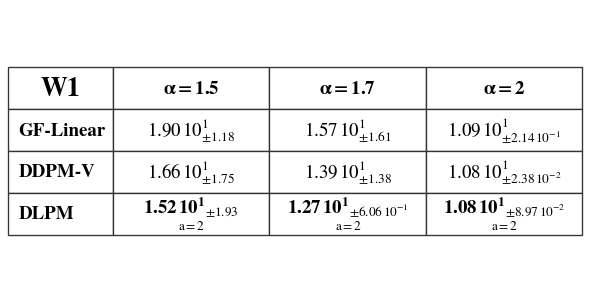

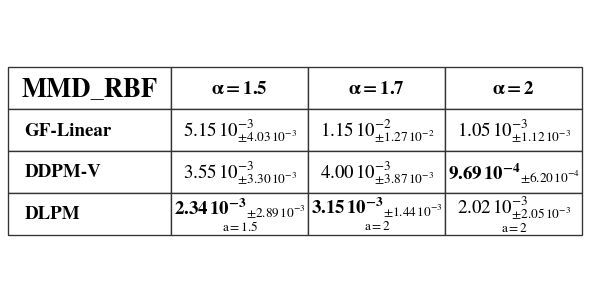

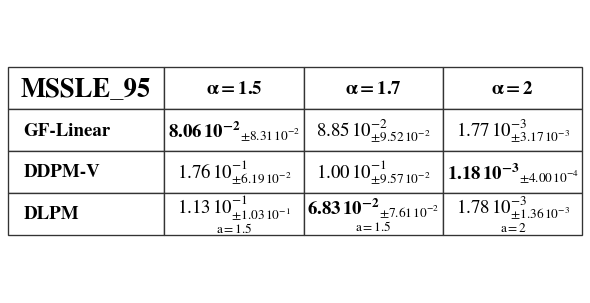

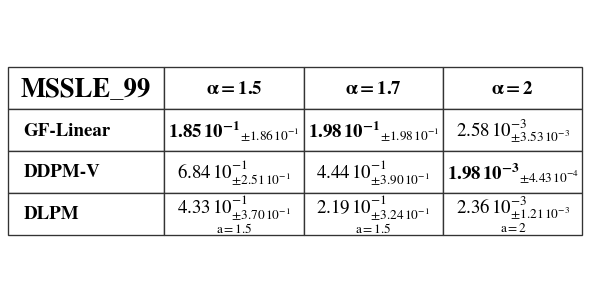

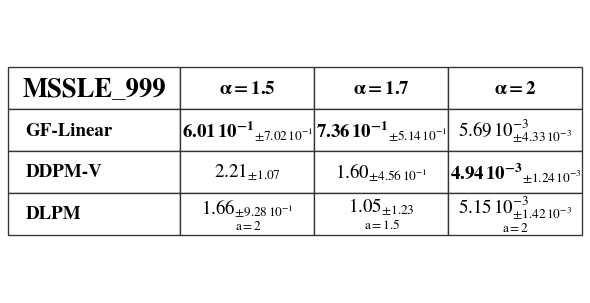

In [4]:
baseline_summary = summarize_test_metrics(
    baseline_scalars,
    ["dataset_alpha", "model_label", "model_alpha"],
)

for metric_name in PERF_METRICS:
    render_metric_table(
        baseline_summary,
        metric_name,
        row_key="model_label",
        col_key="dataset_alpha",
        col_labels={alpha: rf"$\mathbf{{\alpha={alpha:.3g}}}$" for alpha in sorted(baseline_summary["dataset_alpha"].dropna().unique())},
        corner_text=metric_name,
    )


/tmp/ipykernel_622321/2779535530.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


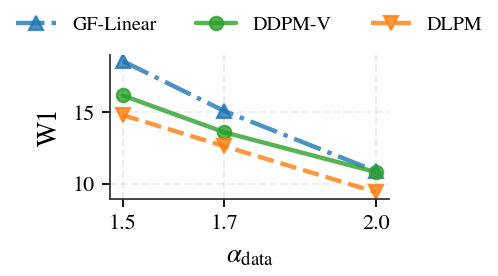

/tmp/ipykernel_622321/2779535530.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


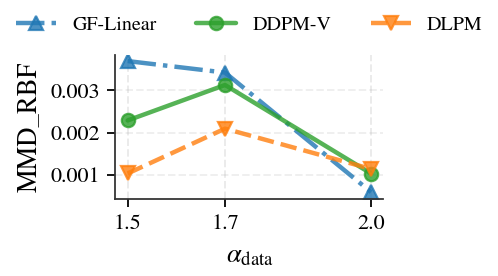

/tmp/ipykernel_622321/2779535530.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


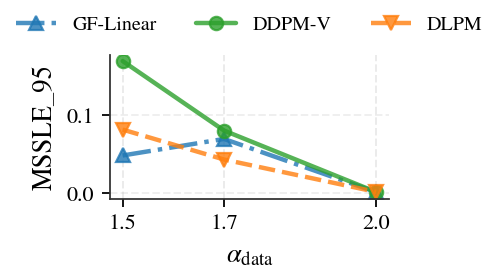

/tmp/ipykernel_622321/2779535530.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


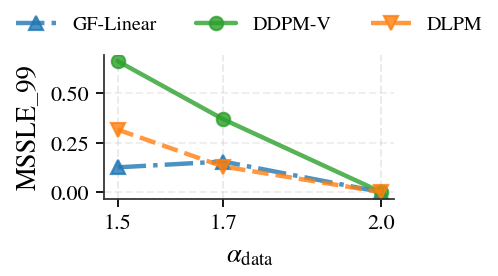

/tmp/ipykernel_622321/2779535530.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


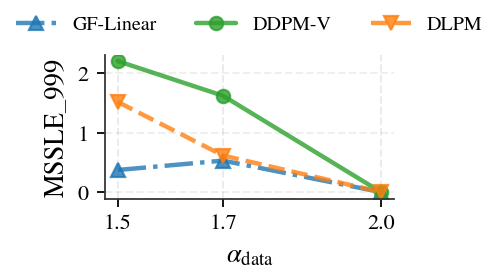

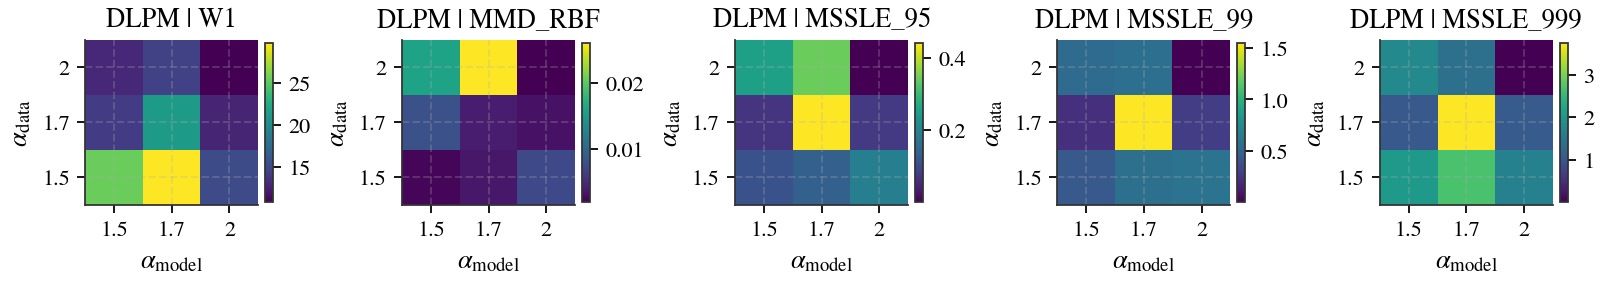

In [33]:
alpha_values = sorted(baseline_summary["dataset_alpha"].dropna().unique())
label_order = ordered_labels(baseline_summary["model_label"].dropna().unique())

baseline_test = baseline_scalars[baseline_scalars["source"] == "test_metrics"].copy()
robust_baseline = (
    baseline_test.groupby(["dataset_alpha", "model_label", "model_alpha", "metric_name"], dropna=False)["value"]
    .agg(median="median", std=lambda s: float(s.std(ddof=0)))
    .reset_index()
)

for metric_name in PERF_METRICS:
    sub = robust_baseline[robust_baseline["metric_name"] == metric_name].copy()
    rows = []
    for _, group in sub.groupby(["dataset_alpha", "model_label"], dropna=False):
        if "model_alpha" in group.columns and not group["model_alpha"].isna().all():
            rows.append(group.nsmallest(1, "median").iloc[0].to_dict())
        else:
            rows.append(group.iloc[0].to_dict())
    best = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(3.0, 2.0), constrained_layout=True)
    for label in label_order:
        group = best[best["model_label"] == label].sort_values("dataset_alpha")
        if group.empty:
            continue
        style = STYLE_MAP.get(label, {"color": "0.2", "linestyle": "solid", "marker": "o"})
        x = group["dataset_alpha"].to_numpy(dtype=float)
        y = group["median"].to_numpy(dtype=float)
        ax.plot(x, y, color=style["color"], linestyle=style["linestyle"], marker=style["marker"], lw=2.0, alpha=0.8, label=label)
    ax.set_xlabel(r"$\alpha_{\mathrm{data}}$")
    ax.set_ylabel(metric_name)
    ax.set_xticks(alpha_values)
    ax.grid(alpha=0.2, axis="y")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=9)

    fig.tight_layout()
    plt.show()

if "DLPM" in set(baseline_summary["model_label"]):
    dlpm_summary = baseline_summary[baseline_summary["model_label"] == "DLPM"].copy()
    metrics = PERF_METRICS
    fig, axes = plt.subplots(1, len(metrics), figsize=(2.0 * len(metrics), 1.75), constrained_layout=True, squeeze=False)
    for ax, metric_name in zip(axes.flat, metrics):
        sub = dlpm_summary[dlpm_summary["metric_name"] == metric_name].copy()
        if sub.empty:
            ax.axis("off")
            continue
        pivot = sub.pivot(index="dataset_alpha", columns="model_alpha", values="mean").sort_index().sort_index(axis=1)
        image = ax.imshow(pivot.values, origin="lower", aspect="auto", interpolation="nearest")
        ax.set_title(f"DLPM | {metric_name}")
        ax.set_xlabel(r"$\alpha_{\mathrm{model}}$")
        ax.set_ylabel(r"$\alpha_{\mathrm{data}}$")
        ax.set_xticks(np.arange(len(pivot.columns)), [f"{value:.3g}" for value in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)), [f"{value:.3g}" for value in pivot.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.show()


## 02. Dimension Effect

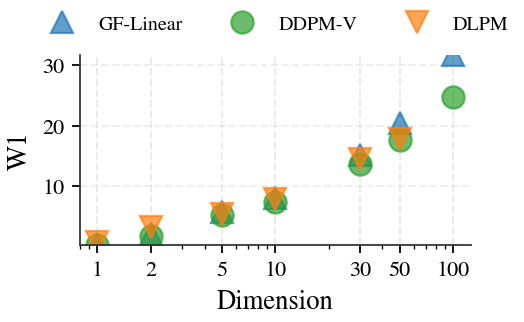

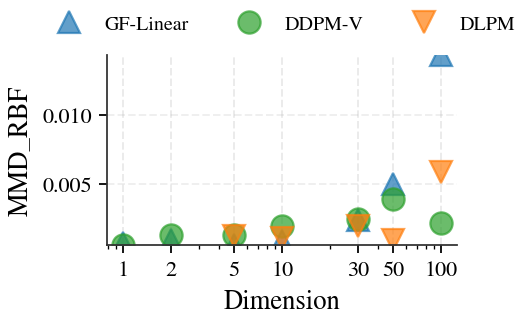

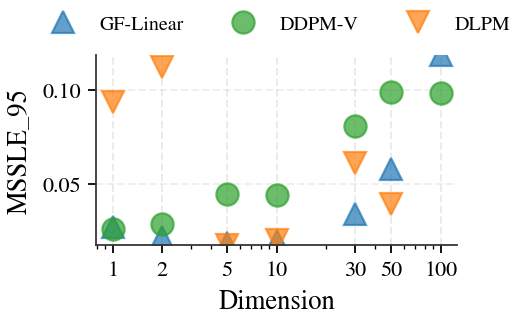

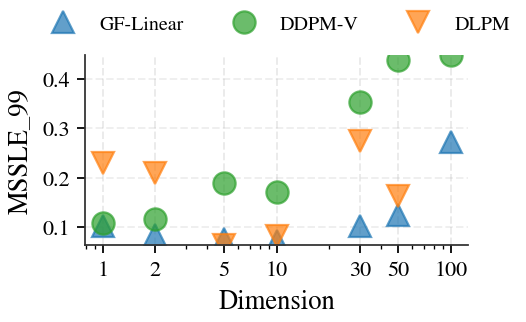

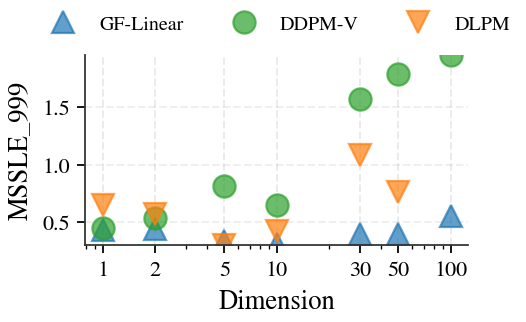

In [34]:
dimension_summary = summarize_test_metrics(
    dimension_scalars,
    ["dataset_dim", "model_label", "model_alpha"],
)

dimension_test = dimension_scalars[dimension_scalars["source"] == "test_metrics"].copy()
robust_dimension = (
    dimension_test.groupby(["dataset_dim", "model_label", "model_alpha", "metric_name"], dropna=False)["value"]
    .agg(median="median", std=lambda s: float(s.std(ddof=0)))
    .reset_index()
)

dims = sorted(dimension_summary["dataset_dim"].dropna().unique())
label_order = ordered_labels(dimension_summary["model_label"].dropna().unique())

for metric_name in PERF_METRICS:
    sub = robust_dimension[robust_dimension["metric_name"] == metric_name].copy()
    rows = []
    for _, group in sub.groupby(["dataset_dim", "model_label"], dropna=False):
        if "model_alpha" in group.columns and not group["model_alpha"].isna().all():
            rows.append(group.nsmallest(1, "median").iloc[0].to_dict())
        else:
            rows.append(group.iloc[0].to_dict())
    best = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(3.25, 2.0), constrained_layout=True)
    y_min, y_max = [], []
    for label in label_order:
        group = best[best["model_label"] == label].sort_values("dataset_dim")
        if group.empty:
            continue
        style = STYLE_MAP.get(label, {"color": "0.2", "linestyle": "solid", "marker": "o"})
        x = group["dataset_dim"].to_numpy(dtype=float)
        y = group["median"].to_numpy(dtype=float)
        ax.plot(x, y, color=style["color"], linestyle="", marker=style["marker"], markersize=10, alpha=0.7, label=label)
        y_min.append(np.min(y))
        y_max.append(np.max(y))

    ax.set_ylim(bottom=float(np.min(y_min)), top=float(np.median(y_max)))
    ax.set_xscale("log")
    ax.set_xlabel("Dimension")
    ax.set_ylabel(metric_name)
    ax.set_xticks(dims)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(alpha=0.2, axis="y")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=9)
    plt.show()


## 03. Mode-Collapse Stress Test

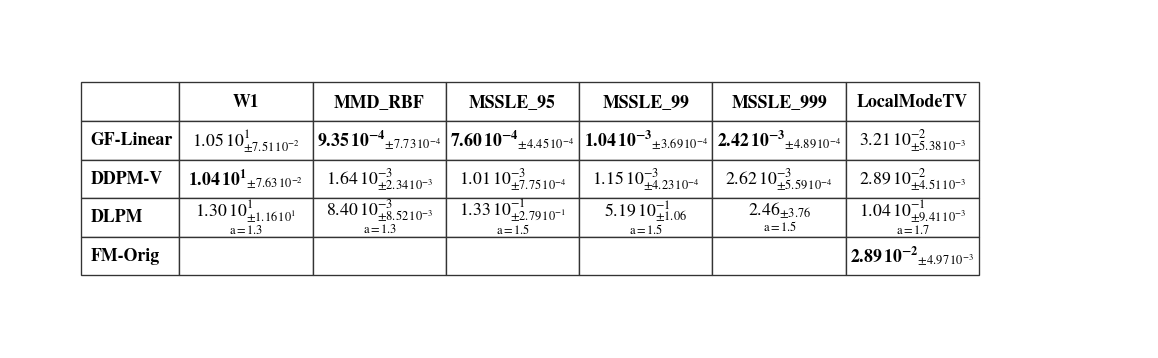

In [31]:
mode_perf_summary = summarize_test_metrics(
    mode_scalars,
    ["dataset_dim", "model_label", "model_alpha"],
)
mode_tv_summary = (
    mode_tv_frame.groupby(["dataset_dim", "model_label", "model_alpha", "metric_name"], dropna=False)["value"]
    .agg(mean="mean", std=lambda s: float(s.std(ddof=0)))
    .reset_index()
)
mode_summary = pd.concat([mode_perf_summary, mode_tv_summary], ignore_index=True)
mode_dim = int(mode_summary["dataset_dim"].dropna().iloc[0])
mode_metrics = PERF_METRICS + ["LocalModeTV"]
mode_rows = []
for metric_name in mode_metrics:
    winners = best_parameter_rows(mode_summary, metric_name, ["dataset_dim", "model_label"])
    mode_rows.append(winners)
mode_best = pd.concat(mode_rows, ignore_index=True)
label_order = ordered_labels(mode_best["model_label"].dropna().unique())

mode_table = pd.DataFrame("", index=label_order, columns=mode_metrics, dtype=object)
for metric_name in mode_metrics:
    sub = mode_best[mode_best["metric_name"] == metric_name].copy()
    best_idx = sub["mean"].idxmin()
    best_label = sub.loc[best_idx, "model_label"]
    for _, row in sub.iterrows():
        mode_table.loc[row["model_label"], metric_name] = format_mean_std_latex(
            row["mean"],
            row["std"],
            caption=alpha_caption(row.get("model_alpha", np.nan)),
            bold=row["model_label"] == best_label,
        )

fig, ax = plt.subplots(1, 1, figsize=(0.9 + 1.1 * len(mode_metrics), 0.9 + 0.4 * len(mode_table.index)))
styled_table(
    ax,
    mode_table.values,
    list(mode_table.index),
    list(mode_table.columns),
    fontsize=8,
    scale=(0.7, 1.3),
    corner_text="",
)
fig.tight_layout()
plt.show()
